# Causes of Death by World Bank Region & Income Class (1980–2023)

In [2]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

## 1. Load Raw Data

In [3]:
world_raw = pd.read_csv('world.csv')

income_raw = pd.read_csv('incomeDeaths.csv')

gdpc_raw = pd.read_csv('gdpc.csv')

YEAR_START, YEAR_END = 1980, 2023

print('world.csv   :', world_raw.shape)
print('incomeDeaths.csv:', income_raw.shape)
print('gdpc.csv    :', gdpc_raw.shape)

world.csv   : (6468, 18)
incomeDeaths.csv: (3696, 11)
gdpc.csv    : (266, 70)


## 2. Cleaning

In [4]:
year_cols = [str(y) for y in range(YEAR_START, YEAR_END + 1)]

gdpc_long = gdpc_raw.melt(
    id_vars=['Country Name', 'Country Code'],
    value_vars=year_cols,
    var_name='year',
    value_name='gdp_per_capita'
)
gdpc_long['year'] = gdpc_long['year'].astype(int)

region_gdp_map = {
    'East Asia & Pacific - WB'         : 'East Asia & Pacific',
    'Europe & Central Asia - WB'       : 'Europe & Central Asia',
    'Latin America & Caribbean - WB'   : 'Latin America & Caribbean',
    'Middle East & North Africa - WB'  : 'Middle East, North Africa, Afghanistan & Pakistan',
    'North America'                    : 'North America',
    'South Asia - WB'                  : 'South Asia',
    'Sub-Saharan Africa - WB'          : 'Sub-Saharan Africa',
}

income_gdp_map = {
    'World Bank High Income'         : 'High income',
    'World Bank Low Income'          : 'Low income',
    'World Bank Lower Middle Income' : 'Lower middle income',
    'World Bank Upper Middle Income' : 'Upper middle income',
}

gdpc_indexed = (
    gdpc_long
    .set_index(['Country Name', 'year'])['gdp_per_capita']
)

print('GDP long shape:', gdpc_long.shape)
print('Sample lookup (East Asia & Pacific, 2010):',
      gdpc_indexed.get(('East Asia & Pacific', 2010), 'NOT FOUND'))

GDP long shape: (11704, 4)
Sample lookup (East Asia & Pacific, 2010): 7784.344658223


## 3. Build `df_region`

In [5]:
region_deaths = world_raw[
    (world_raw['year'] >= YEAR_START) & (world_raw['year'] <= YEAR_END)
].copy()

region_deaths = region_deaths.rename(columns={
    'location_name' : 'region',
    'cause_name'    : 'cause',
    'metric_name'   : 'metric',
    'measure_name'  : 'measure',
    'val'           : 'death_share_pct',
    'upper'         : 'upper_pct',
    'lower'         : 'lower_pct',
})

region_deaths = region_deaths[[
    'region', 'cause', 'year', 'death_share_pct', 'upper_pct', 'lower_pct'
]]

region_deaths['gdp_country'] = region_deaths['region'].map(region_gdp_map)

region_deaths['gdp_per_capita_usd'] = region_deaths.apply(
    lambda r: gdpc_indexed.get((r['gdp_country'], r['year']), np.nan), axis=1
)

region_deaths = region_deaths.drop(columns='gdp_country')

df_region = region_deaths.sort_values(['region', 'cause', 'year']).reset_index(drop=True)

print('df_region shape:', df_region.shape)
print('\nRegions:', df_region['region'].nunique(), '->', sorted(df_region['region'].unique()))
print('Causes :', df_region['cause'].nunique())
print('Years  :', df_region['year'].min(), '–', df_region['year'].max())
print('\nGDP coverage (non-null):',
      df_region['gdp_per_capita_usd'].notna().sum(), '/', len(df_region))

df_region.head(10)

df_region shape: (6468, 7)

Regions: 7 -> ['East Asia & Pacific - WB', 'Europe & Central Asia - WB', 'Latin America & Caribbean - WB', 'Middle East & North Africa - WB', 'North America', 'South Asia - WB', 'Sub-Saharan Africa - WB']
Causes : 21
Years  : 1980 – 2023

GDP coverage (non-null): 6468 / 6468


,region,cause,year,death_share_pct,upper_pct,lower_pct,gdp_per_capita_usd
0,East Asia & Pacific - WB,Cardiovascular diseases,1980,0.3186,0.3575,0.2703,1188.1785
1,East Asia & Pacific - WB,Cardiovascular diseases,1981,0.3207,0.3585,0.2742,1289.2773
2,East Asia & Pacific - WB,Cardiovascular diseases,1982,0.3219,0.3579,0.2786,1242.6616
3,East Asia & Pacific - WB,Cardiovascular diseases,1983,0.3213,0.3581,0.2800,1301.6217
4,East Asia & Pacific - WB,Cardiovascular diseases,1984,0.3199,0.3561,0.2775,1371.6239
5,East Asia & Pacific - WB,Cardiovascular diseases,1985,0.3190,0.3549,0.2787,1425.0739
6,East Asia & Pacific - WB,Cardiovascular diseases,1986,0.3199,0.3542,0.2805,1833.4874
7,East Asia & Pacific - WB,Cardiovascular diseases,1987,0.3212,0.3551,0.2832,2118.3190
8,East Asia & Pacific - WB,Cardiovascular diseases,1988,0.3242,0.3585,0.2843,2505.8672
9,East Asia & Pacific - WB,Cardiovascular diseases,1989,0.3264,0.3621,0.2848,2569.5527


## 4. Build `df_income`

In [6]:
income_deaths = income_raw[
    (income_raw['year'] >= YEAR_START) & (income_raw['year'] <= YEAR_END)
].copy()

income_deaths = income_deaths.rename(columns={
    'location' : 'income_class',
    'cause'    : 'cause',
    'val'      : 'death_share_pct',
    'upper'    : 'upper_pct',
    'lower'    : 'lower_pct',
})

income_deaths = income_deaths[[
    'income_class', 'cause', 'year', 'death_share_pct', 'upper_pct', 'lower_pct'
]]

income_deaths['gdp_country'] = income_deaths['income_class'].map(income_gdp_map)

income_deaths['gdp_per_capita_usd'] = income_deaths.apply(
    lambda r: gdpc_indexed.get((r['gdp_country'], r['year']), np.nan), axis=1
)

income_deaths = income_deaths.drop(columns='gdp_country')

df_income = income_deaths.sort_values(['income_class', 'cause', 'year']).reset_index(drop=True)

print('df_income shape:', df_income.shape)
print('\nIncome classes:', df_income['income_class'].nunique(), '->', sorted(df_income['income_class'].unique()))
print('Causes :', df_income['cause'].nunique())
print('Years  :', df_income['year'].min(), '–', df_income['year'].max())
print('\nGDP coverage (non-null):',
      df_income['gdp_per_capita_usd'].notna().sum(), '/', len(df_income))

df_income.sort_values("year").head(10)

df_income shape: (3696, 7)

Income classes: 4 -> ['World Bank High Income', 'World Bank Low Income', 'World Bank Lower Middle Income', 'World Bank Upper Middle Income']
Causes : 21
Years  : 1980 – 2023

GDP coverage (non-null): 3696 / 3696


,income_class,cause,year,death_share_pct,upper_pct,lower_pct,gdp_per_capita_usd
1936,World Bank Lower Middle Income,Diabetes and kidney diseases,1980,0.0183,0.0219,0.0148,385.7892
836,World Bank High Income,Transport injuries,1980,0.0269,0.0283,0.0257,8449.5621
3476,World Bank Upper Middle Income,Self-harm and interpersonal violence,1980,0.0276,0.0333,0.0233,836.7354
440,World Bank High Income,Neoplasms,1980,0.2155,0.2199,0.2082,8449.5621
1144,World Bank Low Income,HIV/AIDS and sexually transmitted infections,1980,0.0068,0.0121,0.0033,427.3882
1408,World Bank Low Income,Neurological disorders,1980,0.0068,0.0117,0.0039,427.3882
2992,World Bank Upper Middle Income,HIV/AIDS and sexually transmitted infections,1980,0.0015,0.0023,0.0010,836.7354
3652,World Bank Upper Middle Income,Unintentional injuries,1980,0.0497,0.0563,0.0446,836.7354
704,World Bank High Income,Self-harm and interpersonal violence,1980,0.0258,0.0266,0.0251,8449.5621
528,World Bank High Income,Nutritional deficiencies,1980,0.0008,0.0009,0.0007,8449.5621


In [7]:
region_totals = (
    df_region.groupby(['region', 'year'])['death_share_pct']
    .sum()
    .reset_index()
    .rename(columns={'death_share_pct': 'total_pct'})
)

In [8]:
income_totals = (
    df_income.groupby(['income_class', 'year'])['death_share_pct']
    .sum()
    .reset_index()
    .rename(columns={'death_share_pct': 'total_pct'})
)

In [9]:
sample_region = (
    df_region[(df_region['cause'] == 'Cardiovascular diseases') & (df_region['year'] == 2010)]
    [['region', 'death_share_pct', 'gdp_per_capita_usd']]
    .sort_values('death_share_pct', ascending=False)
    .reset_index(drop=True)
)
print('Cardiovascular disease share by region (2010):')
print(sample_region.to_string())

Cardiovascular disease share by region (2010):
                            region  death_share_pct  gdp_per_capita_usd
0       Europe & Central Asia - WB           0.4620          23702.4750
1  Middle East & North Africa - WB           0.4209           4867.9294
2         East Asia & Pacific - WB           0.3605           7784.3447
3                    North America           0.3178          48545.7753
4                  South Asia - WB           0.2477           1294.0273
5   Latin America & Caribbean - WB           0.2459           9183.9688
6          Sub-Saharan Africa - WB           0.1037           1642.6413


In [10]:
sample_income = (
    df_income[(df_income['income_class'] == 'World Bank High Income') & (df_income['year'] == 2023)]
    [['cause', 'death_share_pct', 'gdp_per_capita_usd']]
    .sort_values('death_share_pct', ascending=False)
    .reset_index(drop=True)
)
print('Cause-of-death shares for High Income countries (2023):')
print(sample_income.to_string())

Cause-of-death shares for High Income countries (2023):
                                           cause  death_share_pct  gdp_per_capita_usd
0                        Cardiovascular diseases           0.3222          48608.1948
1                                      Neoplasms           0.2629          48608.1948
2                         Neurological disorders           0.0935          48608.1948
3                   Diabetes and kidney diseases           0.0556          48608.1948
4                   Chronic respiratory diseases           0.0504          48608.1948
5                             Digestive diseases           0.0486          48608.1948
6        Respiratory infections and tuberculosis           0.0473          48608.1948
7                         Unintentional injuries           0.0328          48608.1948
8           Self-harm and interpersonal violence           0.0232          48608.1948
9                Other non-communicable diseases           0.0211          48608.194

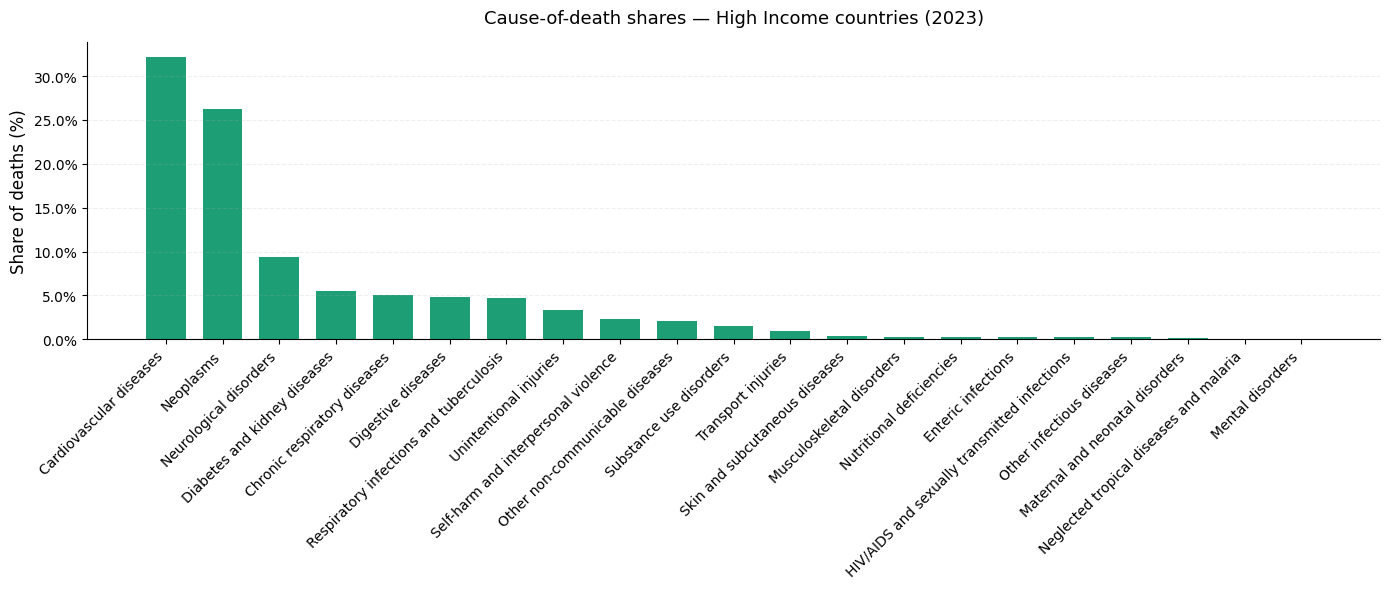

In [11]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

sample_income = (
    df_income[(df_income['income_class'] == 'World Bank High Income') & (df_income['year'] == 2023)]
    [['cause', 'death_share_pct', 'gdp_per_capita_usd']]
    .sort_values('death_share_pct', ascending=False)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(14, 6))

causes = sample_income['cause']
shares = sample_income['death_share_pct'] * 100

ax.bar(causes, shares, color='#1D9E75', width=0.7)

ax.set_ylabel('Share of deaths (%)', fontsize=12)
ax.set_title('Cause-of-death shares — High Income countries (2023)', fontsize=13, pad=14)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
ax.set_xticks(range(len(causes)))
ax.set_xticklabels(causes, rotation=45, ha='right', fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.2, linestyle='--')

plt.tight_layout()
plt.show()

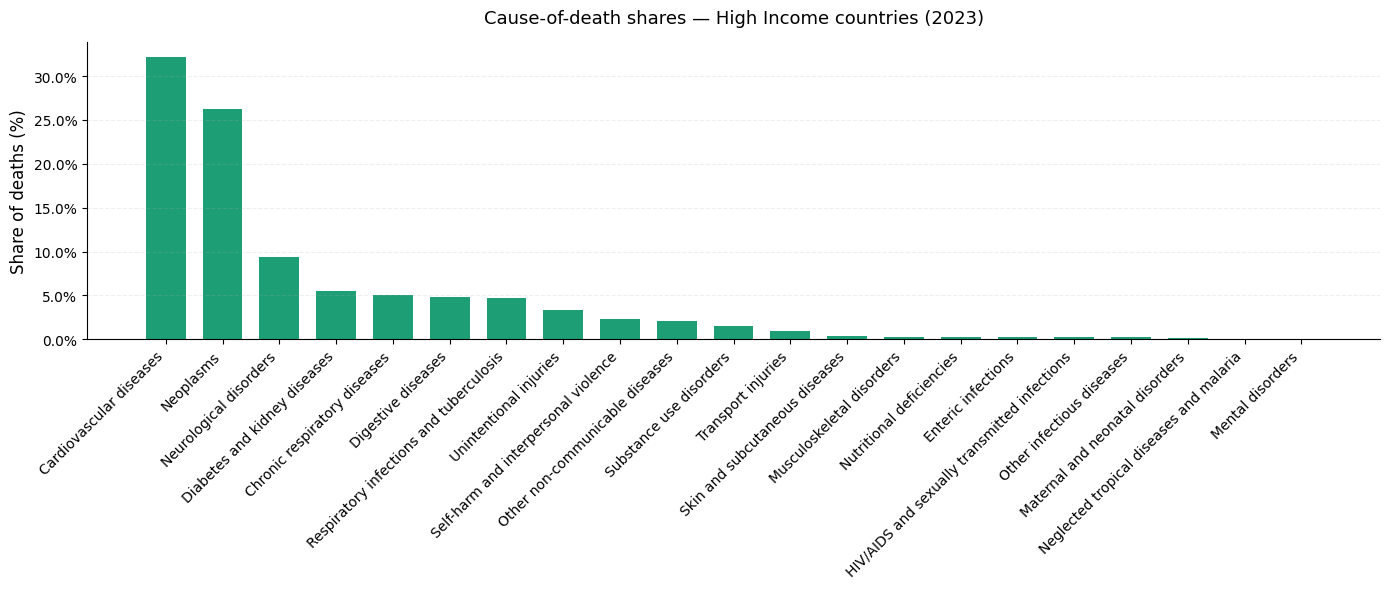

In [12]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

sample_income = (
    df_income[(df_income['income_class'] == 'World Bank High Income') & (df_income['year'] == 2023)]
    [['cause', 'death_share_pct', 'gdp_per_capita_usd']]
    .sort_values('death_share_pct', ascending=False)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(14, 6))

causes = sample_income['cause']
shares = sample_income['death_share_pct'] * 100

ax.bar(causes, shares, color='#1D9E75', width=0.7)

ax.set_ylabel('Share of deaths (%)', fontsize=12)
ax.set_title('Cause-of-death shares — High Income countries (2023)', fontsize=13, pad=14)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
ax.set_xticks(range(len(causes)))
ax.set_xticklabels(causes, rotation=45, ha='right', fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.2, linestyle='--')

plt.tight_layout()
plt.show()

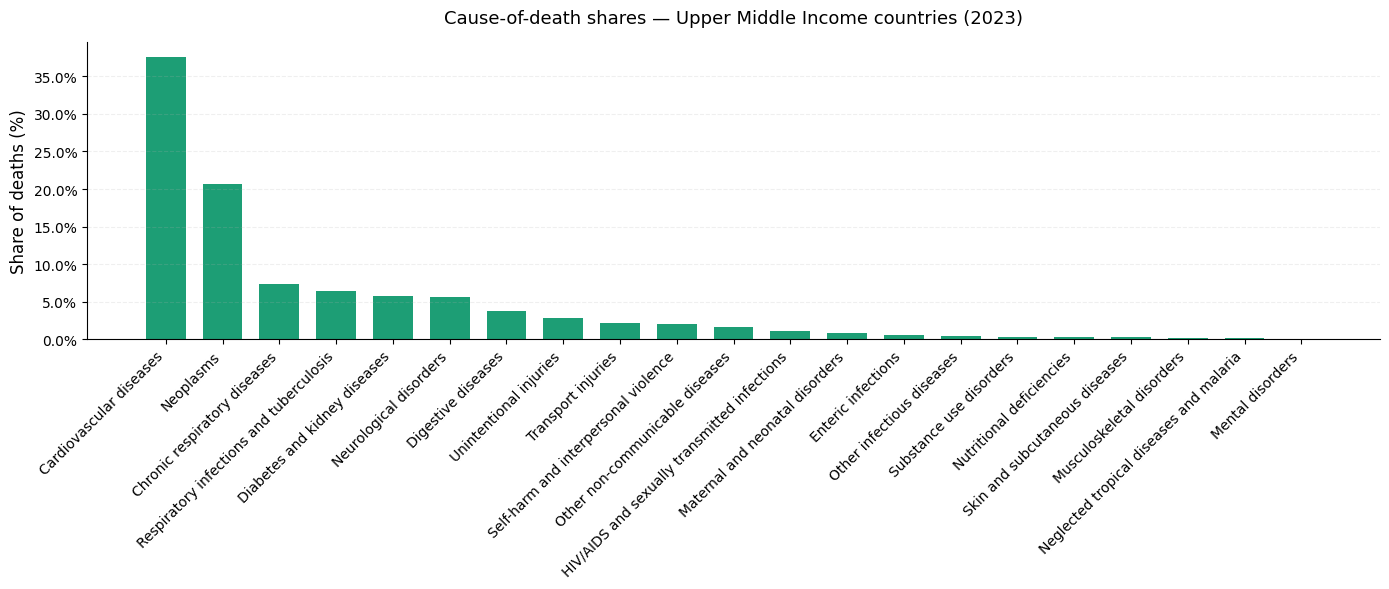

In [13]:
sample_income = (
    df_income[(df_income['income_class'] == 'World Bank Upper Middle Income') & (df_income['year'] == 2023)]
    [['cause', 'death_share_pct', 'gdp_per_capita_usd']]
    .sort_values('death_share_pct', ascending=False)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(14, 6))

causes = sample_income['cause']
shares = sample_income['death_share_pct'] * 100

ax.bar(causes, shares, color='#1D9E75', width=0.7)

ax.set_ylabel('Share of deaths (%)', fontsize=12)
ax.set_title('Cause-of-death shares — Upper Middle Income countries (2023)', fontsize=13, pad=14)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
ax.set_xticks(range(len(causes)))
ax.set_xticklabels(causes, rotation=45, ha='right', fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.2, linestyle='--')

plt.tight_layout()
plt.show()

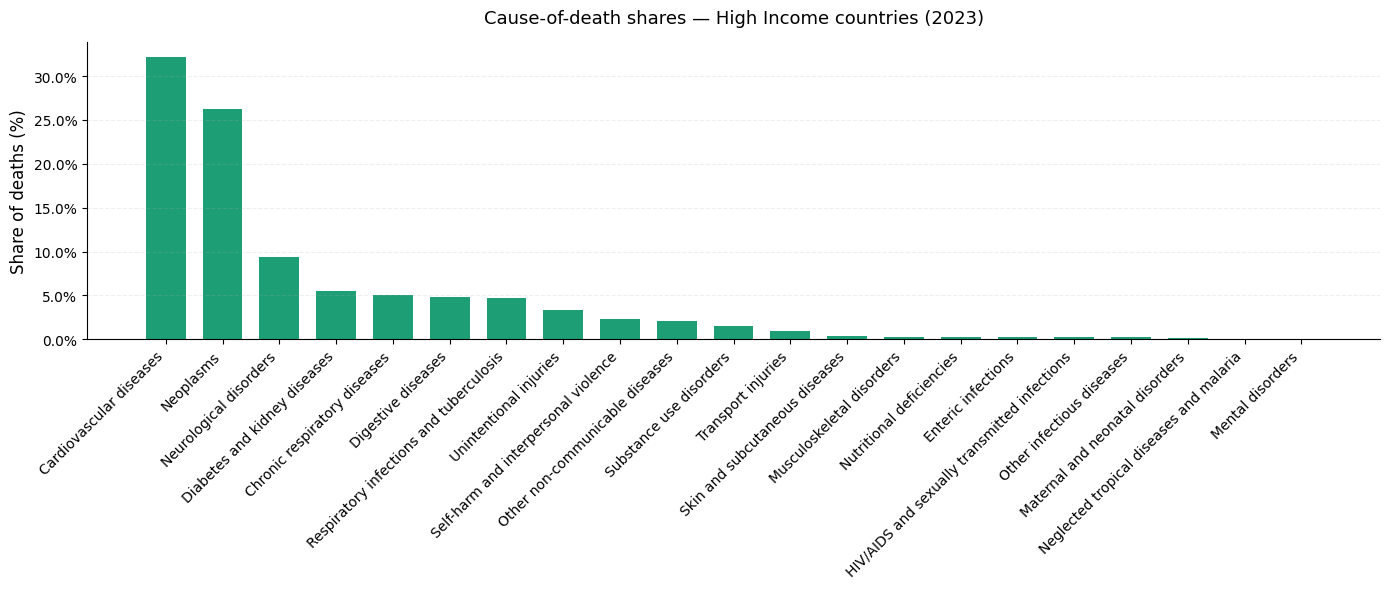

In [14]:
sample_income = (
    df_income[(df_income['income_class'] == 'World Bank High Income') & (df_income['year'] == 2023)]
    [['cause', 'death_share_pct', 'gdp_per_capita_usd']]
    .sort_values('death_share_pct', ascending=False)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(14, 6))

causes = sample_income['cause']
shares = sample_income['death_share_pct'] * 100

ax.bar(causes, shares, color='#1D9E75', width=0.7)

ax.set_ylabel('Share of deaths (%)', fontsize=12)
ax.set_title('Cause-of-death shares — High Income countries (2023)', fontsize=13, pad=14)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
ax.set_xticks(range(len(causes)))
ax.set_xticklabels(causes, rotation=45, ha='right', fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.2, linestyle='--')

plt.tight_layout()
plt.show()

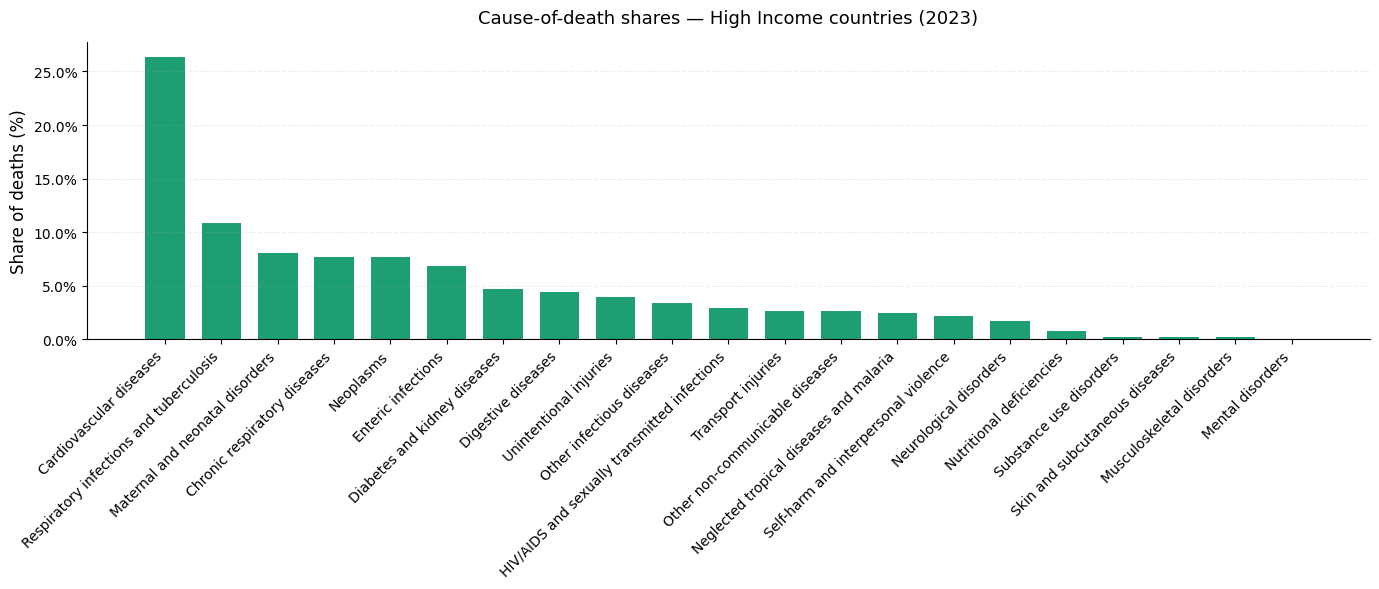

In [15]:
sample_income = (
    df_income[(df_income['income_class'] == 'World Bank Lower Middle Income') & (df_income['year'] == 2013)]
    [['cause', 'death_share_pct', 'gdp_per_capita_usd']]
    .sort_values('death_share_pct', ascending=False)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(14, 6))

causes = sample_income['cause']
shares = sample_income['death_share_pct'] * 100

ax.bar(causes, shares, color='#1D9E75', width=0.7)

ax.set_ylabel('Share of deaths (%)', fontsize=12)
ax.set_title('Cause-of-death shares — High Income countries (2023)', fontsize=13, pad=14)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
ax.set_xticks(range(len(causes)))
ax.set_xticklabels(causes, rotation=45, ha='right', fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.2, linestyle='--')

plt.tight_layout()
plt.show()

Feature matrix shape: (176, 21)

Global Silhouette Score: 0.3910
  World Bank High Income                   0.5244
  World Bank Low Income                    0.3305
  World Bank Lower Middle Income           0.3343
  World Bank Upper Middle Income           0.3748

Neighborhood Purity (k=10)
  Global mean: 0.9994
  World Bank High Income                   1.0000
  World Bank Low Income                    1.0000
  World Bank Lower Middle Income           1.0000
  World Bank Upper Middle Income           0.9977


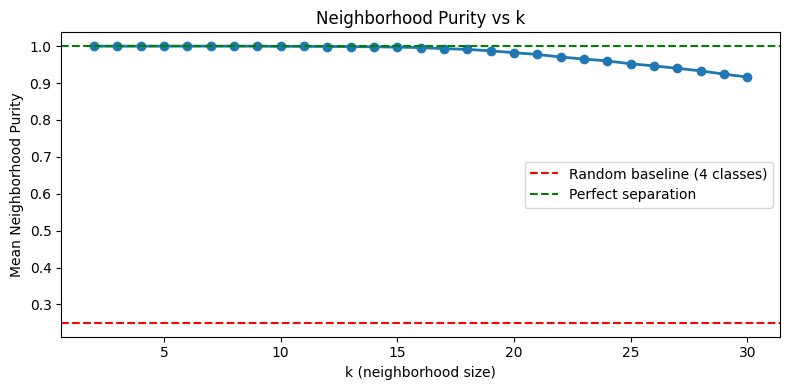

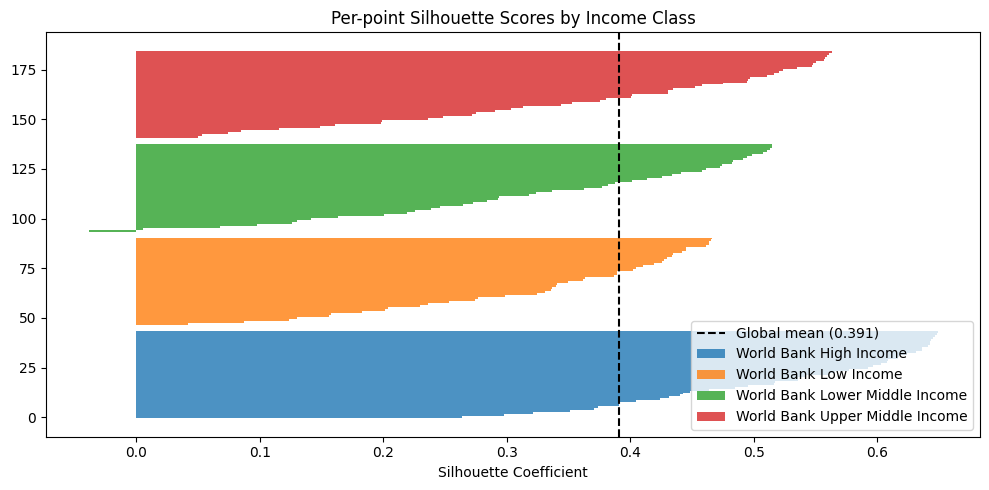

In [30]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import seaborn as sns

death_pivot = df_income.pivot_table(
    index=['income_class', 'year'],
    columns='cause',
    values='death_share_pct'
).reset_index()

df_points = death_pivot.copy()

feature_cols = [c for c in df_points.columns if c not in ['income_class', 'year']]
X_raw = df_points[feature_cols].values
labels = df_points['income_class'].values

le = LabelEncoder()
y = le.fit_transform(labels)

X = StandardScaler().fit_transform(X_raw)

print(f"Feature matrix shape: {X.shape}")

sil_global = silhouette_score(X, y)
sil_samples = silhouette_samples(X, y)

print(f"\nGlobal Silhouette Score: {sil_global:.4f}")

sil_per_class = {}
for i, cls in enumerate(le.classes_):
    mask = y == i
    sil_per_class[cls] = sil_samples[mask].mean()
    print(f"  {cls:<40} {sil_per_class[cls]:.4f}")

def neighborhood_purity(X, y, k=10):

    nn = NearestNeighbors(n_neighbors=k + 1)
    nn.fit(X)
    distances, indices = nn.kneighbors(X)

    purities = []
    for i, neighbors in enumerate(indices):
        neighbors = neighbors[1:]
        same_class = np.sum(y[neighbors] == y[i])
        purities.append(same_class / k)

    return np.array(purities)

K = 10
purity_per_point = neighborhood_purity(X, y, k=K)
print(f"\nNeighborhood Purity (k={K})")
print(f"  Global mean: {purity_per_point.mean():.4f}")

purity_per_class = {}
for i, cls in enumerate(le.classes_):
    mask = y == i
    purity_per_class[cls] = purity_per_point[mask].mean()
    print(f"  {cls:<40} {purity_per_class[cls]:.4f}")

k_values = range(2, 31)
mean_purities = [neighborhood_purity(X, y, k=k).mean() for k in k_values]

plt.figure(figsize=(8, 4))
plt.plot(k_values, mean_purities, marker='o', linewidth=2)
plt.axhline(0.25, color='red', linestyle='--', label='Random baseline (4 classes)')
plt.axhline(1.0,  color='green', linestyle='--', label='Perfect separation')
plt.xlabel('k (neighborhood size)')
plt.ylabel('Mean Neighborhood Purity')
plt.title('Neighborhood Purity vs k')
plt.legend()
plt.tight_layout()
plt.show()

df_sil = pd.DataFrame({
    'income_class': labels,
    'silhouette':   sil_samples,
    'year':         df_points['year'].values
})

fig, ax = plt.subplots(figsize=(10, 5))
colors = sns.color_palette('tab10', n_colors=4)
y_lower = 0
for i, cls in enumerate(le.classes_):
    vals = np.sort(df_sil[df_sil['income_class'] == cls]['silhouette'].values)
    ax.barh(range(y_lower, y_lower + len(vals)), vals, height=1,
            color=colors[i], alpha=0.8, label=cls)
    y_lower += len(vals) + 3

ax.axvline(sil_global, color='black', linestyle='--', label=f'Global mean ({sil_global:.3f})')
ax.set_xlabel('Silhouette Coefficient')
ax.set_title('Per-point Silhouette Scores by Income Class')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [17]:
death_pivot.head(44)

cause,income_class,year,Cardiovascular diseases,Chronic respiratory diseases,Diabetes and kidney diseases,Digestive diseases,Enteric infections,HIV/AIDS and sexually transmitted infections,Maternal and neonatal disorders,Mental disorders,Musculoskeletal disorders,Neglected tropical diseases and malaria,Neoplasms,Neurological disorders,Nutritional deficiencies,Other infectious diseases,Other non-communicable diseases,Respiratory infections and tuberculosis,Self-harm and interpersonal violence,Skin and subcutaneous diseases,Substance use disorders,Transport injuries,Unintentional injuries
0,World Bank High Income,1980,0.4646,0.0417,0.0273,0.0430,0.0022,0.0008,0.0137,0.0000,0.0021,0.0002,0.2155,0.0349,0.0008,0.0040,0.0165,0.0399,0.0258,0.0009,0.0071,0.0269,0.0323
1,World Bank High Income,1981,0.4629,0.0420,0.0275,0.0428,0.0020,0.0008,0.0130,0.0000,0.0021,0.0002,0.2184,0.0360,0.0008,0.0039,0.0164,0.0394,0.0260,0.0009,0.0071,0.0262,0.0316
2,World Bank High Income,1982,0.4611,0.0425,0.0277,0.0424,0.0019,0.0008,0.0123,0.0000,0.0021,0.0002,0.2217,0.0369,0.0008,0.0038,0.0164,0.0388,0.0260,0.0009,0.0070,0.0255,0.0312
3,World Bank High Income,1983,0.4611,0.0432,0.0280,0.0421,0.0018,0.0008,0.0114,0.0000,0.0021,0.0002,0.2230,0.0378,0.0008,0.0036,0.0162,0.0386,0.0260,0.0010,0.0070,0.0246,0.0307
4,World Bank High Income,1984,0.4607,0.0435,0.0282,0.0419,0.0017,0.0010,0.0108,0.0000,0.0022,0.0002,0.2259,0.0387,0.0008,0.0036,0.0162,0.0362,0.0261,0.0010,0.0067,0.0244,0.0302
5,World Bank High Income,1985,0.4595,0.0436,0.0284,0.0418,0.0016,0.0012,0.0103,0.0000,0.0022,0.0002,0.2297,0.0398,0.0009,0.0035,0.0162,0.0361,0.0253,0.0010,0.0058,0.0239,0.0292
6,World Bank High Income,1986,0.4557,0.0435,0.0288,0.0414,0.0015,0.0016,0.0099,0.0000,0.0023,0.0002,0.2336,0.0413,0.0009,0.0035,0.0163,0.0362,0.0249,0.0011,0.0055,0.0239,0.0282
7,World Bank High Income,1987,0.4528,0.0431,0.0289,0.0410,0.0014,0.0022,0.0095,0.0000,0.0023,0.0001,0.2371,0.0424,0.0009,0.0034,0.0163,0.0352,0.0247,0.0011,0.0055,0.0239,0.0280
8,World Bank High Income,1988,0.4490,0.0433,0.0294,0.0409,0.0013,0.0028,0.0091,0.0000,0.0023,0.0001,0.2392,0.0434,0.0009,0.0032,0.0161,0.0356,0.0246,0.0011,0.0058,0.0240,0.0277
9,World Bank High Income,1989,0.4424,0.0440,0.0301,0.0413,0.0013,0.0036,0.0086,0.0000,0.0023,0.0001,0.2411,0.0444,0.0009,0.0032,0.0160,0.0360,0.0253,0.0011,0.0061,0.0244,0.0279


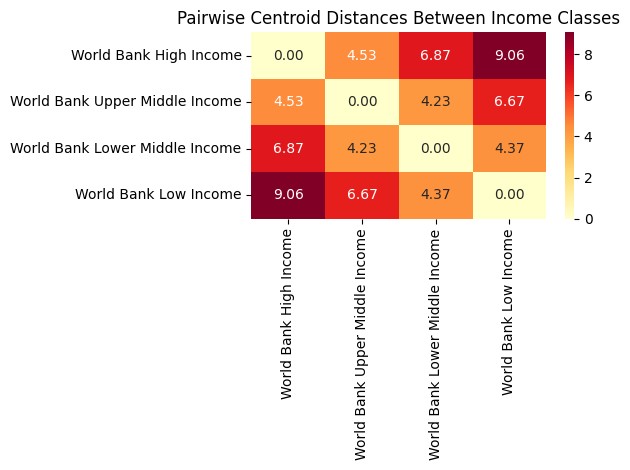

In [31]:
from sklearn.metrics import pairwise_distances

centroids = np.array([X[y == i].mean(axis=0) for i in range(len(le.classes_))])

dist_matrix = pairwise_distances(centroids)

df_dist = pd.DataFrame(dist_matrix, index=le.classes_, columns=le.classes_)

order = [
    'World Bank High Income',
    'World Bank Upper Middle Income',
    'World Bank Lower Middle Income',
    'World Bank Low Income'
]

df_dist_ordered = df_dist.loc[order, order]

sns.heatmap(df_dist_ordered, annot=True, fmt='.2f', cmap='YlOrRd')
plt.title('Pairwise Centroid Distances Between Income Classes')
plt.tight_layout()
plt.show()

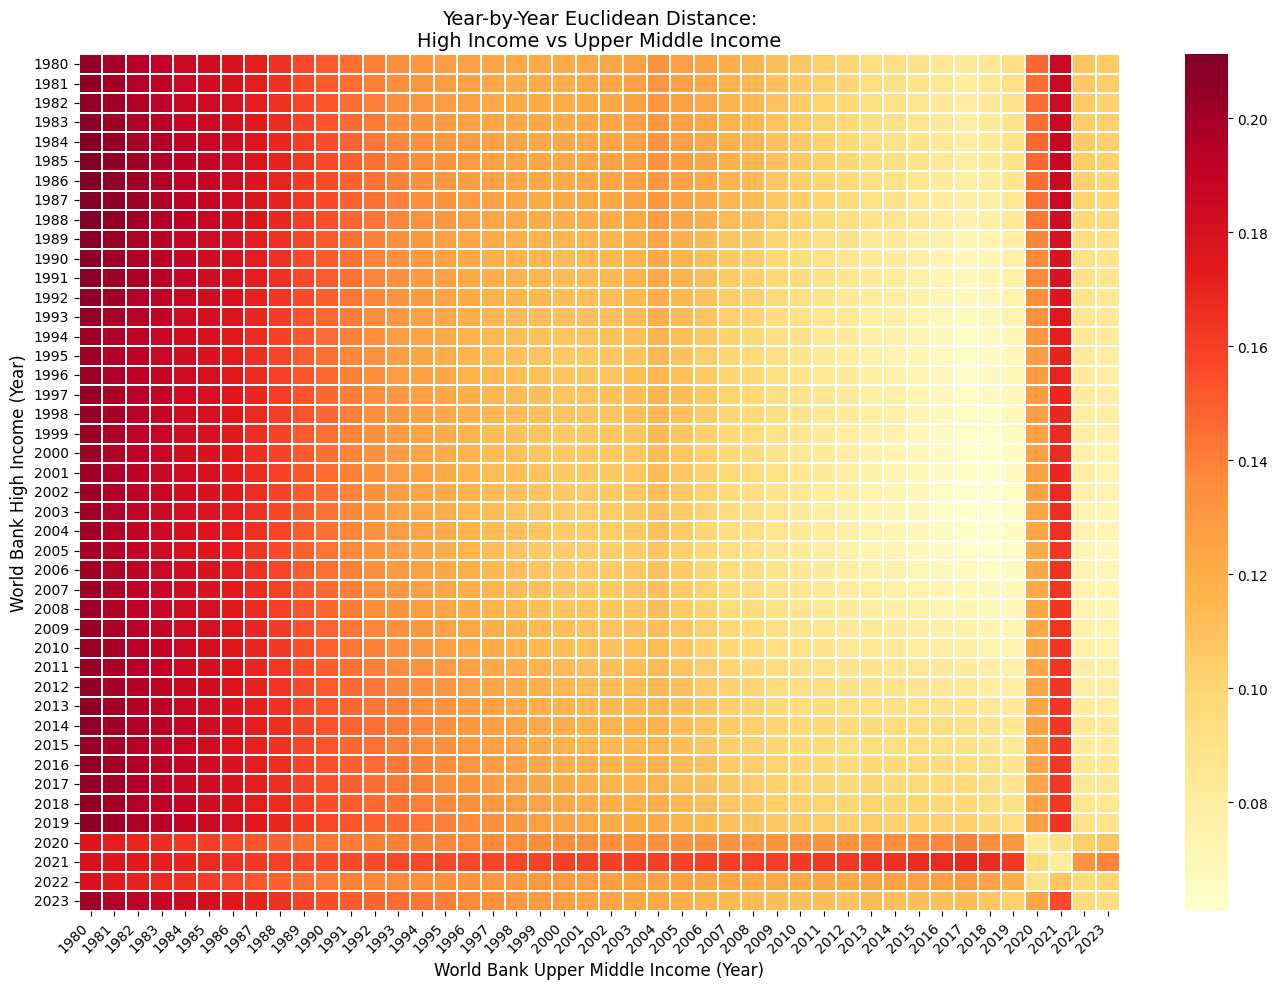

In [19]:
df = death_pivot.copy()

feature_cols = [c for c in df.columns if c not in ['cause', 'income_class', 'year']]

hi = df[df['income_class'] == 'World Bank High Income']
umi = df[df['income_class'] == 'World Bank Upper Middle Income']

years = sorted(set(hi['year'].unique()) & set(umi['year'].unique()))

hi_by_year  = hi.groupby('year')[feature_cols].mean()
umi_by_year = umi.groupby('year')[feature_cols].mean()

dist_matrix = pairwise_distances(
    hi_by_year.loc[years],
    umi_by_year.loc[years],
    metric='euclidean'
)

df_year_dist = pd.DataFrame(dist_matrix, index=years, columns=years)

fig, ax = plt.subplots(figsize=(14, 10))

sns.heatmap(
    df_year_dist,
    annot=False,
    fmt='.3f',
    cmap='YlOrRd',
    ax=ax,
    linewidths=0.3,
    linecolor='white'
)

ax.set_xlabel('World Bank Upper Middle Income (Year)', fontsize=12)
ax.set_ylabel('World Bank High Income (Year)', fontsize=12)
ax.set_title('Year-by-Year Euclidean Distance:\nHigh Income vs Upper Middle Income', fontsize=14)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

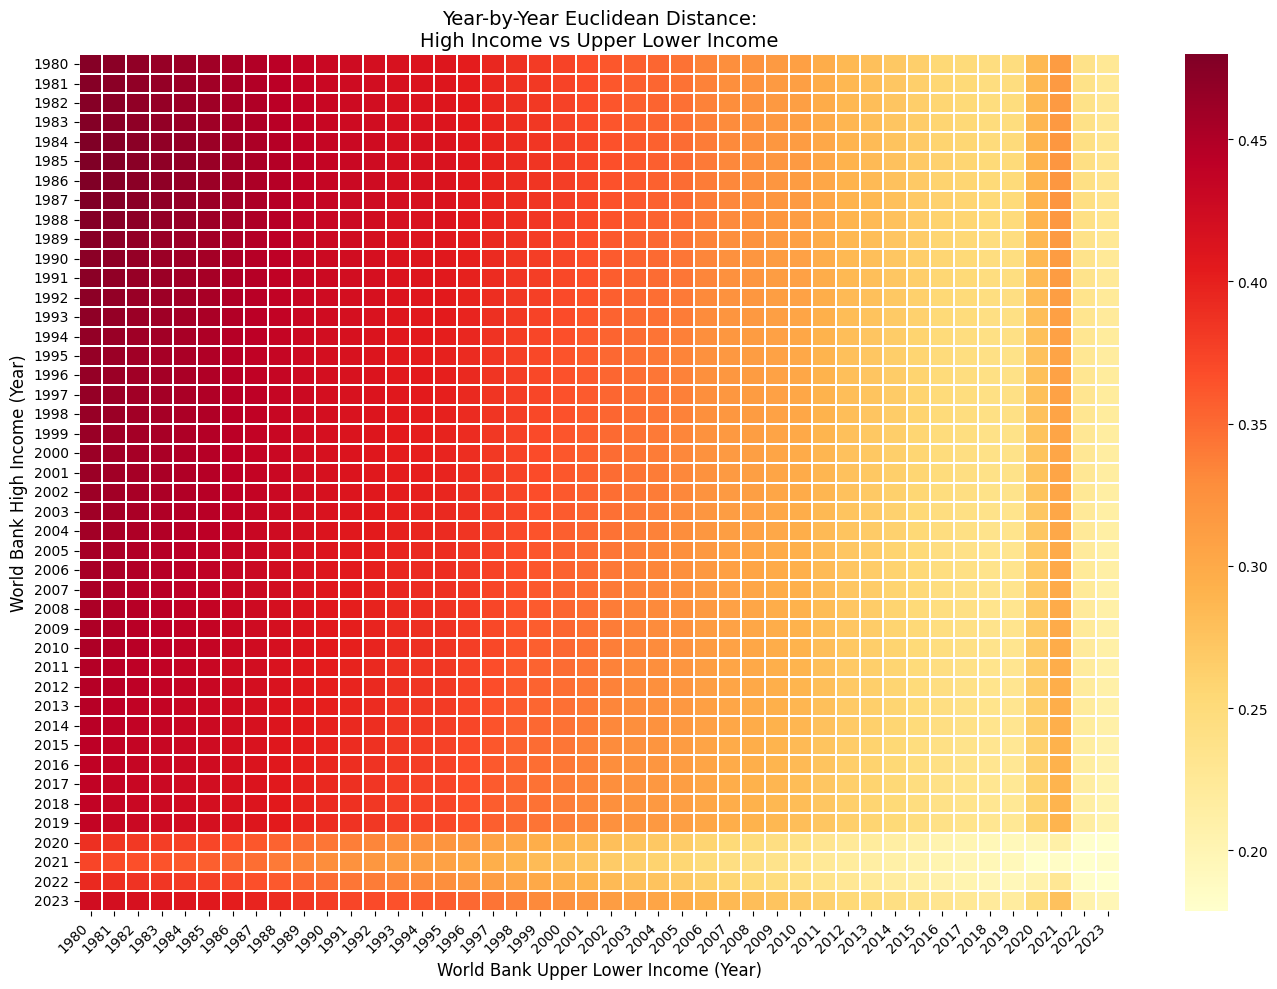

In [20]:
df = death_pivot.copy()

feature_cols = [c for c in df.columns if c not in ['cause', 'income_class', 'year']]

hi = df[df['income_class'] == 'World Bank High Income']
umi = df[df['income_class'] == 'World Bank Lower Middle Income']

years = sorted(set(hi['year'].unique()) & set(umi['year'].unique()))

hi_by_year  = hi.groupby('year')[feature_cols].mean()
umi_by_year = umi.groupby('year')[feature_cols].mean()

dist_matrix = pairwise_distances(
    hi_by_year.loc[years],
    umi_by_year.loc[years],
    metric='euclidean'
)

df_year_dist = pd.DataFrame(dist_matrix, index=years, columns=years)

fig, ax = plt.subplots(figsize=(14, 10))

sns.heatmap(
    df_year_dist,
    annot=False,
    fmt='.3f',
    cmap='YlOrRd',
    ax=ax,
    linewidths=0.3,
    linecolor='white'
)

ax.set_xlabel('World Bank Upper Lower Income (Year)', fontsize=12)
ax.set_ylabel('World Bank High Income (Year)', fontsize=12)
ax.set_title('Year-by-Year Euclidean Distance:\nHigh Income vs Upper Lower Income', fontsize=14)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

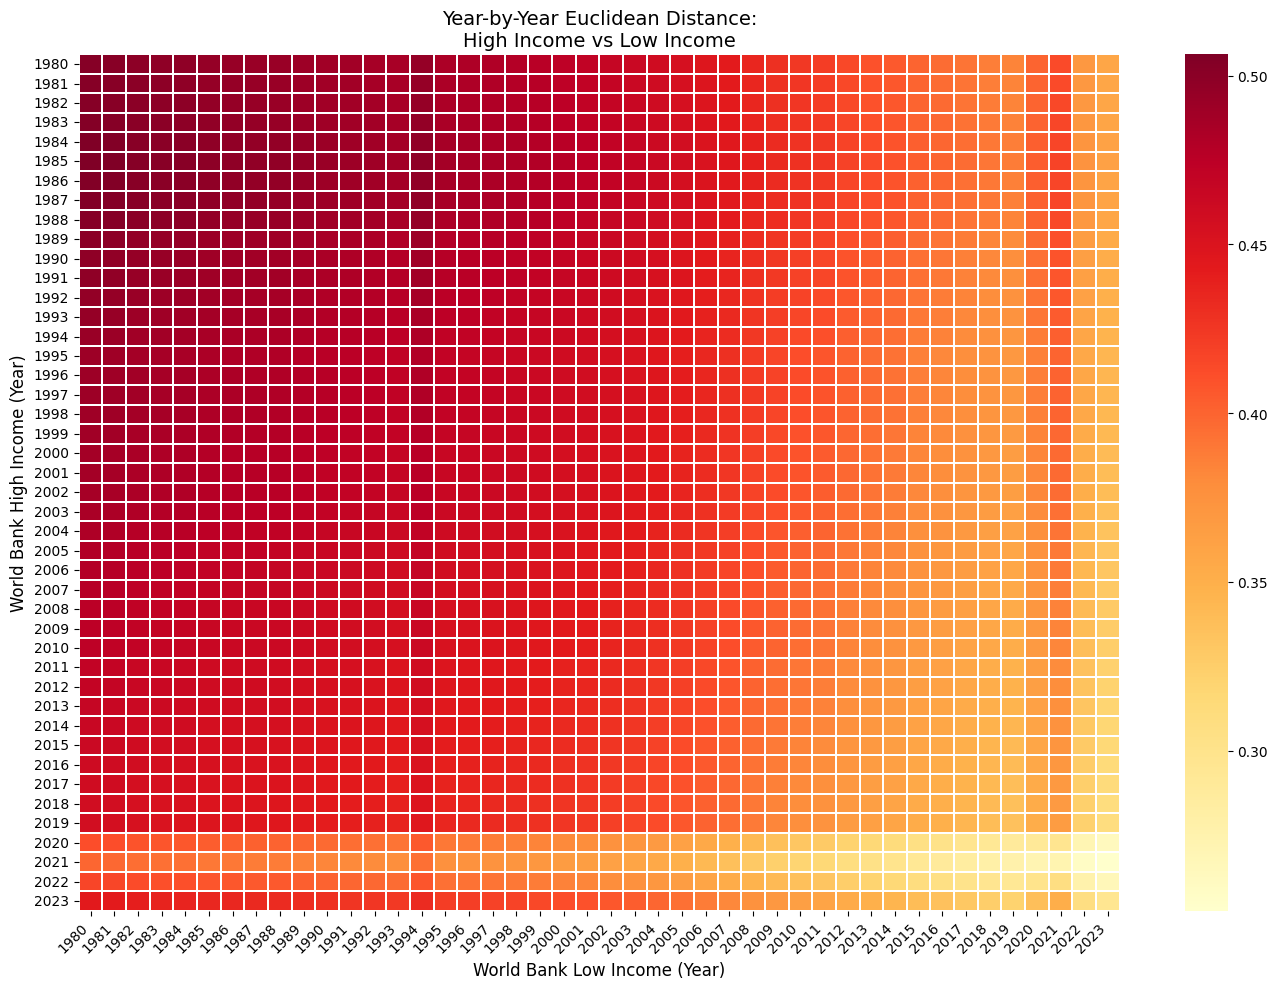

In [21]:
df = death_pivot.copy()

feature_cols = [c for c in df.columns if c not in ['cause', 'income_class', 'year']]

hi = df[df['income_class'] == 'World Bank High Income']
umi = df[df['income_class'] == 'World Bank Low Income']

years = sorted(set(hi['year'].unique()) & set(umi['year'].unique()))

hi_by_year  = hi.groupby('year')[feature_cols].mean()
umi_by_year = umi.groupby('year')[feature_cols].mean()

dist_matrix = pairwise_distances(
    hi_by_year.loc[years],
    umi_by_year.loc[years],
    metric='euclidean'
)

df_year_dist = pd.DataFrame(dist_matrix, index=years, columns=years)

fig, ax = plt.subplots(figsize=(14, 10))

sns.heatmap(
    df_year_dist,
    annot=False,
    fmt='.3f',
    cmap='YlOrRd',
    ax=ax,
    linewidths=0.3,
    linecolor='white'
)

ax.set_xlabel('World Bank Low Income (Year)', fontsize=12)
ax.set_ylabel('World Bank High Income (Year)', fontsize=12)
ax.set_title('Year-by-Year Euclidean Distance:\nHigh Income vs Low Income', fontsize=14)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

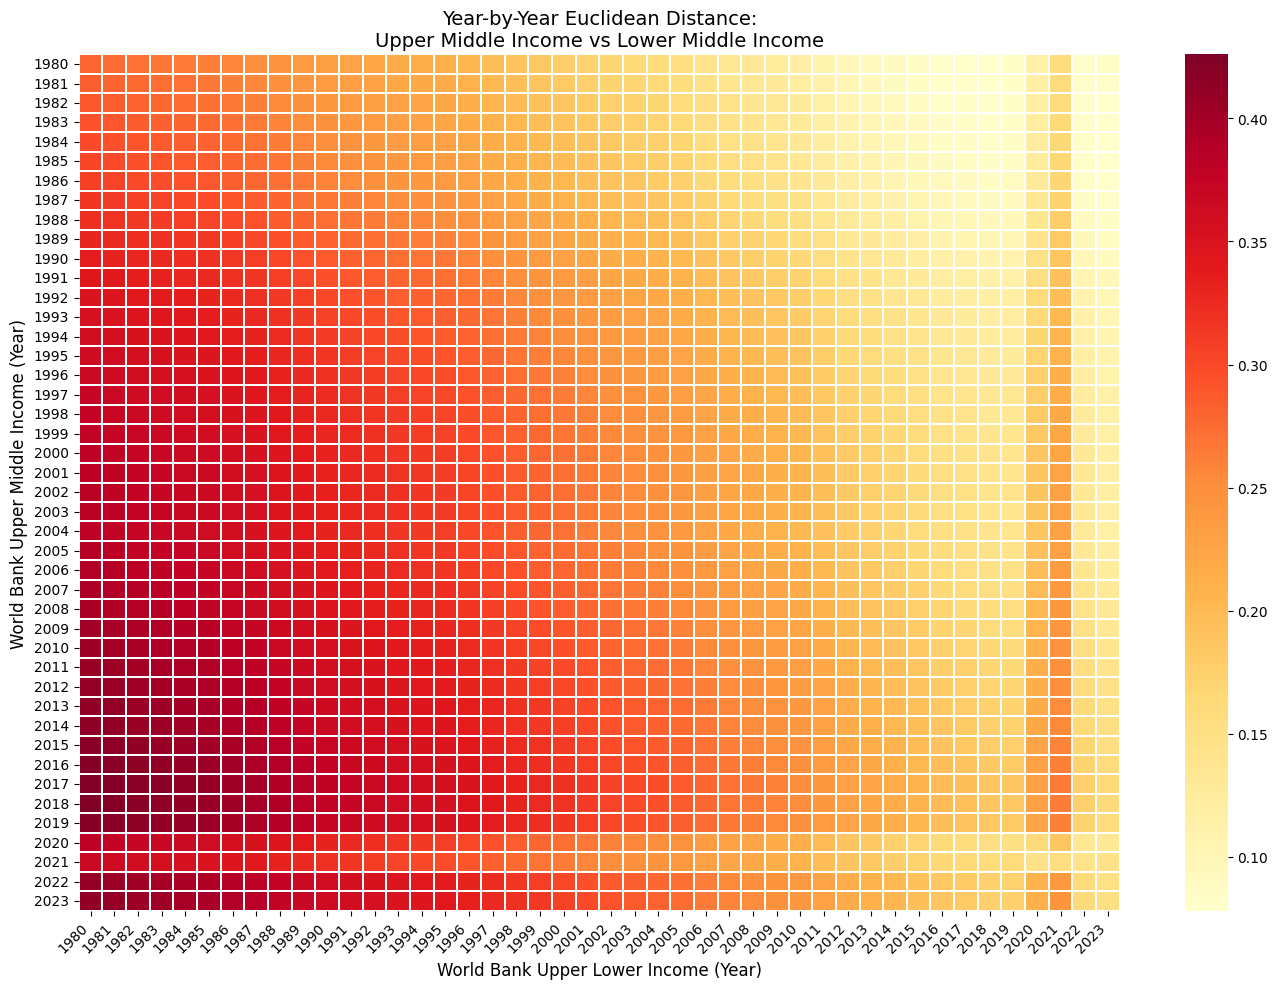

In [22]:
df = death_pivot.copy()

feature_cols = [c for c in df.columns if c not in ['cause', 'income_class', 'year']]

hi = df[df['income_class'] == 'World Bank Upper Middle Income']
umi = df[df['income_class'] == 'World Bank Lower Middle Income']

years = sorted(set(hi['year'].unique()) & set(umi['year'].unique()))

hi_by_year  = hi.groupby('year')[feature_cols].mean()
umi_by_year = umi.groupby('year')[feature_cols].mean()

dist_matrix = pairwise_distances(
    hi_by_year.loc[years],
    umi_by_year.loc[years],
    metric='euclidean'
)

df_year_dist = pd.DataFrame(dist_matrix, index=years, columns=years)

fig, ax = plt.subplots(figsize=(14, 10))

sns.heatmap(
    df_year_dist,
    annot=False,
    fmt='.3f',
    cmap='YlOrRd',
    ax=ax,
    linewidths=0.3,
    linecolor='white'
)

ax.set_xlabel('World Bank Upper Lower Income (Year)', fontsize=12)
ax.set_ylabel('World Bank Upper Middle Income (Year)', fontsize=12)
ax.set_title('Year-by-Year Euclidean Distance:\nUpper Middle Income vs Lower Middle Income', fontsize=14)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

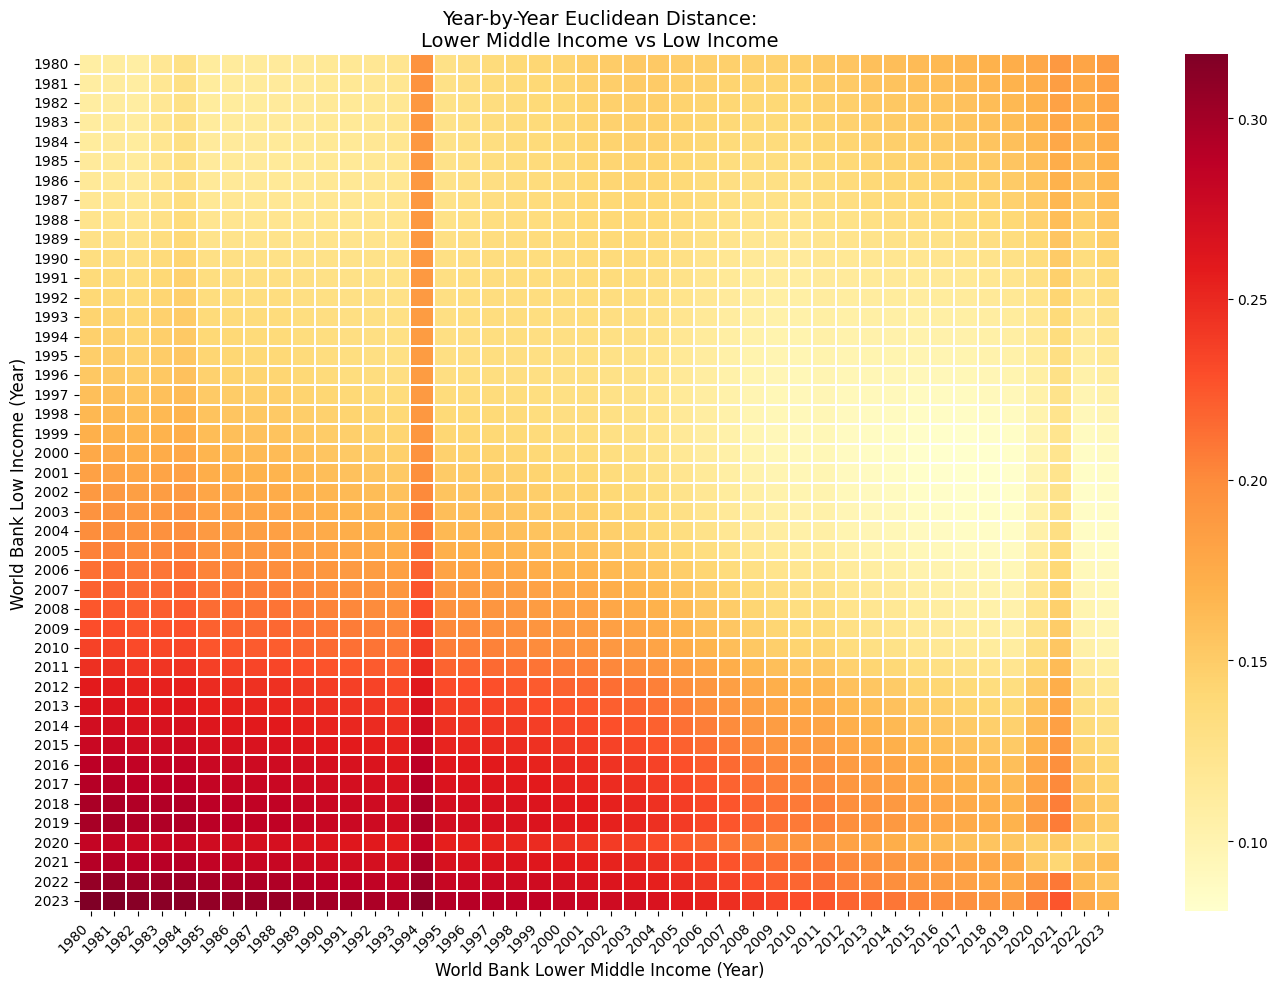

In [23]:
df = death_pivot.copy()

feature_cols = [c for c in df.columns if c not in ['cause', 'income_class', 'year']]

hi = df[df['income_class'] == 'World Bank Lower Middle Income']
umi = df[df['income_class'] == 'World Bank Low Income']

years = sorted(set(hi['year'].unique()) & set(umi['year'].unique()))

hi_by_year  = hi.groupby('year')[feature_cols].mean()
umi_by_year = umi.groupby('year')[feature_cols].mean()

dist_matrix = pairwise_distances(
    hi_by_year.loc[years],
    umi_by_year.loc[years],
    metric='euclidean'
)

df_year_dist = pd.DataFrame(dist_matrix, index=years, columns=years)

fig, ax = plt.subplots(figsize=(14, 10))

sns.heatmap(
    df_year_dist,
    annot=False,
    fmt='.3f',
    cmap='YlOrRd',
    ax=ax,
    linewidths=0.3,
    linecolor='white'
)

ax.set_xlabel('World Bank Lower Middle Income (Year)', fontsize=12)
ax.set_ylabel('World Bank Low Income (Year)', fontsize=12)
ax.set_title('Year-by-Year Euclidean Distance:\nLower Middle Income vs Low Income', fontsize=14)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

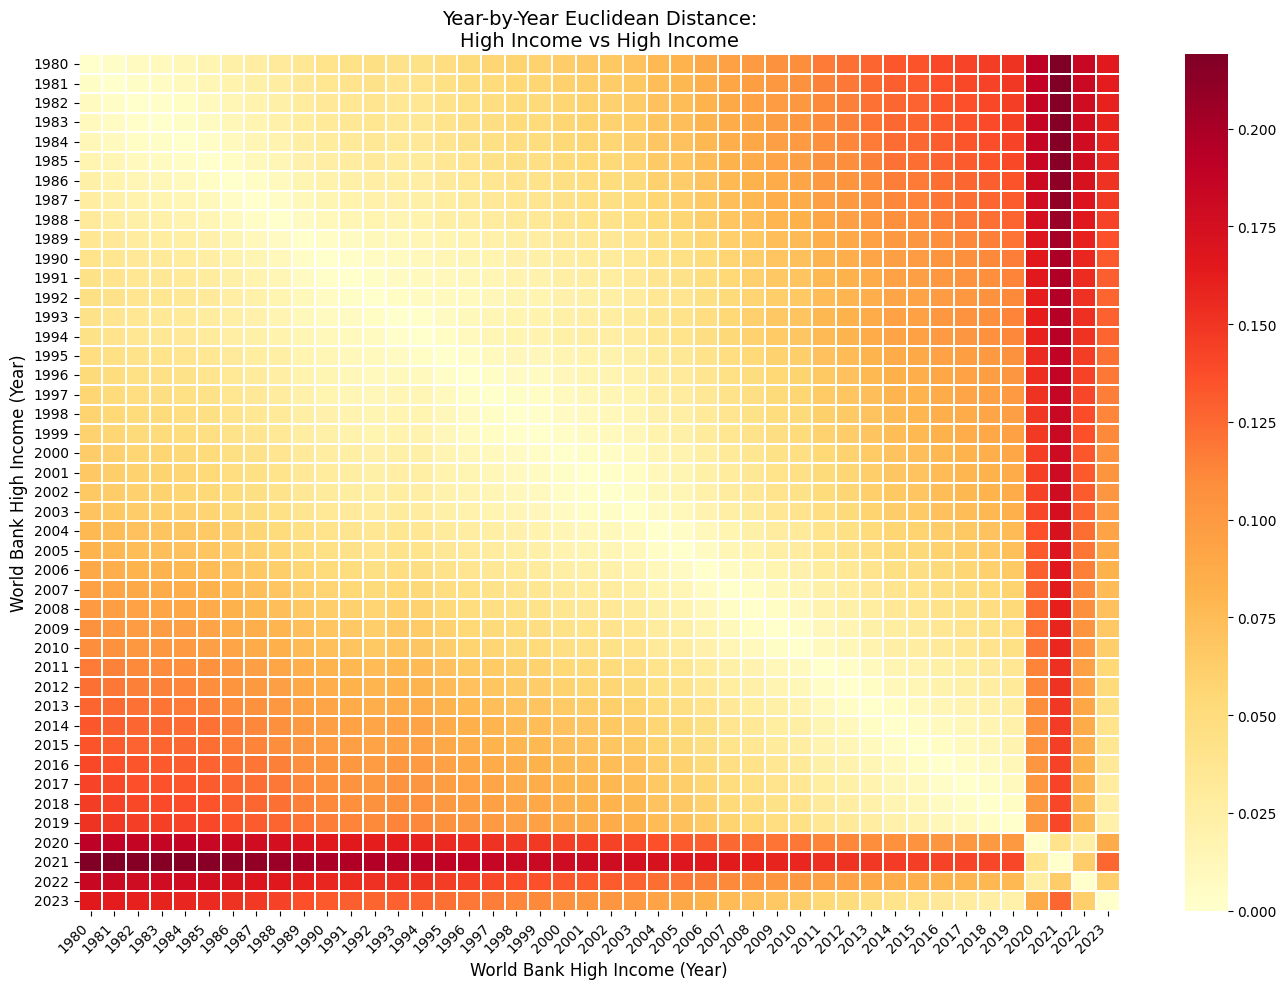

In [24]:
df = death_pivot.copy()

feature_cols = [c for c in df.columns if c not in ['cause', 'income_class', 'year']]

hi = df[df['income_class'] == 'World Bank High Income']
umi = df[df['income_class'] == 'World Bank High Income']

years = sorted(set(hi['year'].unique()) & set(umi['year'].unique()))

hi_by_year  = hi.groupby('year')[feature_cols].mean()
umi_by_year = umi.groupby('year')[feature_cols].mean()

dist_matrix = pairwise_distances(
    hi_by_year.loc[years],
    umi_by_year.loc[years],
    metric='euclidean'
)

df_year_dist = pd.DataFrame(dist_matrix, index=years, columns=years)

fig, ax = plt.subplots(figsize=(14, 10))

sns.heatmap(
    df_year_dist,
    annot=False,
    fmt='.3f',
    cmap='YlOrRd',
    ax=ax,
    linewidths=0.3,
    linecolor='white'
)

ax.set_xlabel('World Bank High Income (Year)', fontsize=12)
ax.set_ylabel('World Bank High Income (Year)', fontsize=12)
ax.set_title('Year-by-Year Euclidean Distance:\nHigh Income vs High Income', fontsize=14)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

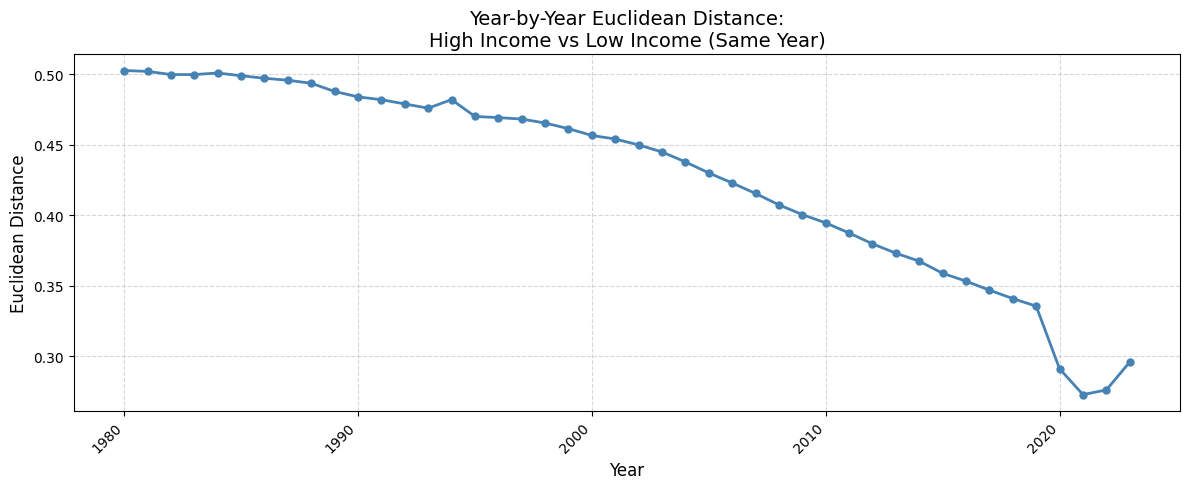

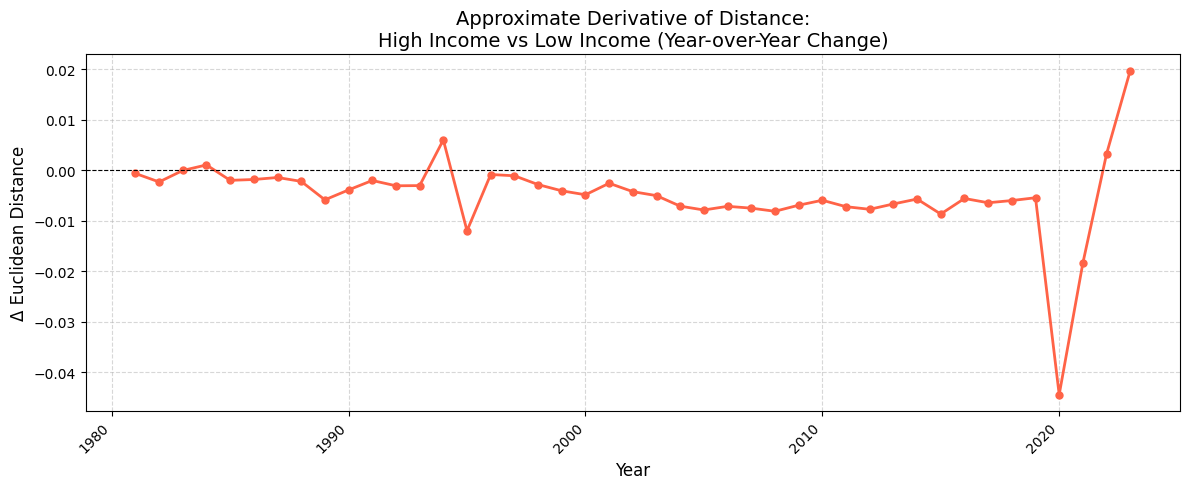

In [25]:
df = death_pivot.copy()
feature_cols = [c for c in df.columns if c not in ['cause', 'income_class', 'year']]

hi = df[df['income_class'] == 'World Bank High Income']
umi = df[df['income_class'] == 'World Bank Low Income']

years = sorted(set(hi['year'].unique()) & set(umi['year'].unique()))

hi_by_year  = hi.groupby('year')[feature_cols].mean()
umi_by_year = umi.groupby('year')[feature_cols].mean()

diagonal_distances = [
    np.linalg.norm(hi_by_year.loc[y].values - umi_by_year.loc[y].values)
    for y in years
]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(years, diagonal_distances, marker='o', linewidth=2, markersize=5, color='steelblue')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Euclidean Distance', fontsize=12)
ax.set_title('Year-by-Year Euclidean Distance:\nHigh Income vs Low Income (Same Year)', fontsize=14)
ax.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

years_mid = years[1:]
deltas = [diagonal_distances[i+1] - diagonal_distances[i] for i in range(len(diagonal_distances)-1)]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(years_mid, deltas, marker='o', linewidth=2, markersize=5, color='tomato')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Δ Euclidean Distance', fontsize=12)
ax.set_title('Approximate Derivative of Distance:\nHigh Income vs Low Income (Year-over-Year Change)', fontsize=14)
ax.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

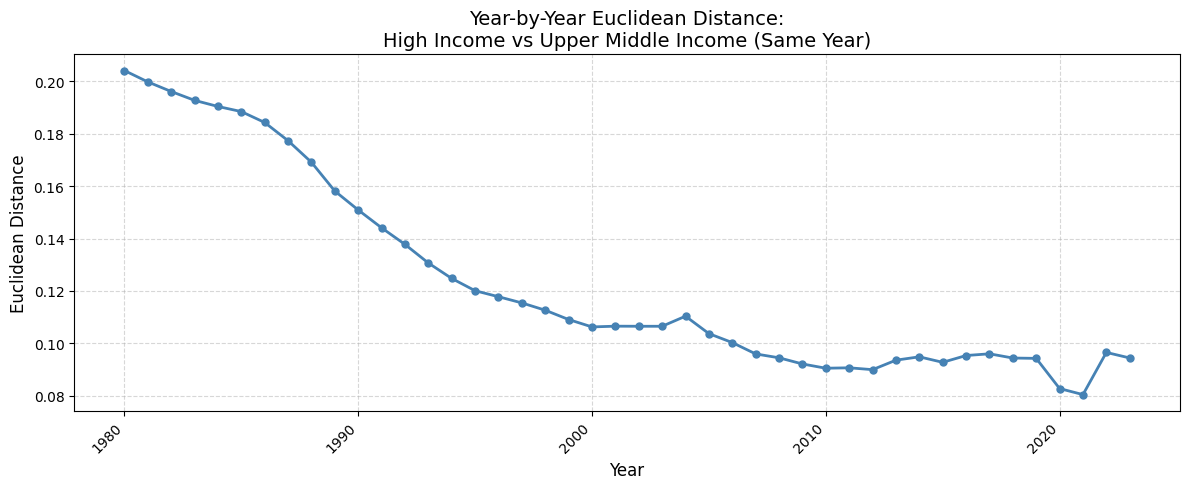

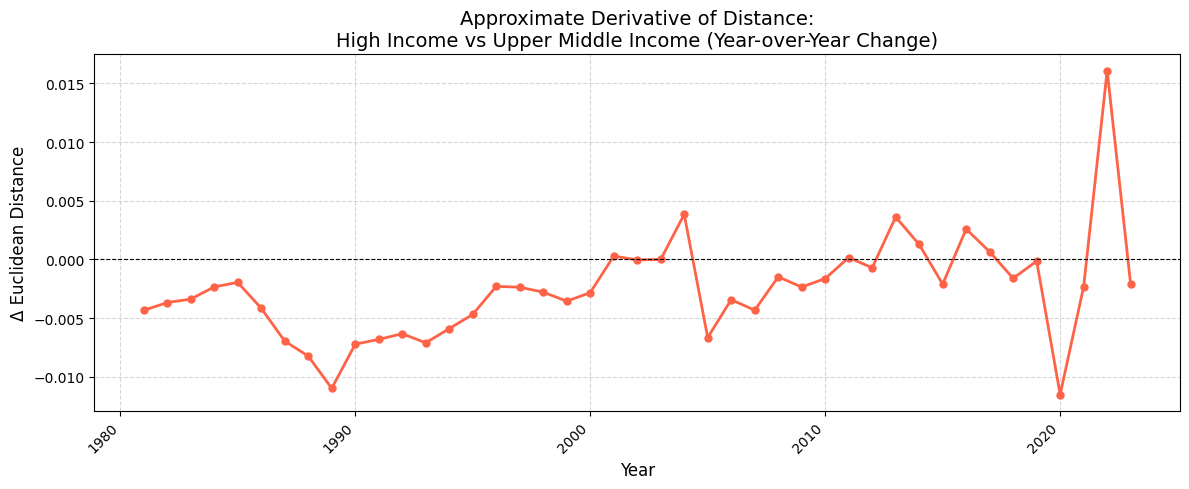

In [26]:
df = death_pivot.copy()
feature_cols = [c for c in df.columns if c not in ['cause', 'income_class', 'year']]

hi = df[df['income_class'] == 'World Bank High Income']
umi = df[df['income_class'] == 'World Bank Upper Middle Income']

years = sorted(set(hi['year'].unique()) & set(umi['year'].unique()))

hi_by_year  = hi.groupby('year')[feature_cols].mean()
umi_by_year = umi.groupby('year')[feature_cols].mean()

diagonal_distances = [
    np.linalg.norm(hi_by_year.loc[y].values - umi_by_year.loc[y].values)
    for y in years
]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(years, diagonal_distances, marker='o', linewidth=2, markersize=5, color='steelblue')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Euclidean Distance', fontsize=12)
ax.set_title('Year-by-Year Euclidean Distance:\nHigh Income vs Upper Middle Income (Same Year)', fontsize=14)
ax.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

years_mid = years[1:]
deltas = [diagonal_distances[i+1] - diagonal_distances[i] for i in range(len(diagonal_distances)-1)]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(years_mid, deltas, marker='o', linewidth=2, markersize=5, color='tomato')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Δ Euclidean Distance', fontsize=12)
ax.set_title('Approximate Derivative of Distance:\nHigh Income vs Upper Middle Income (Year-over-Year Change)', fontsize=14)
ax.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

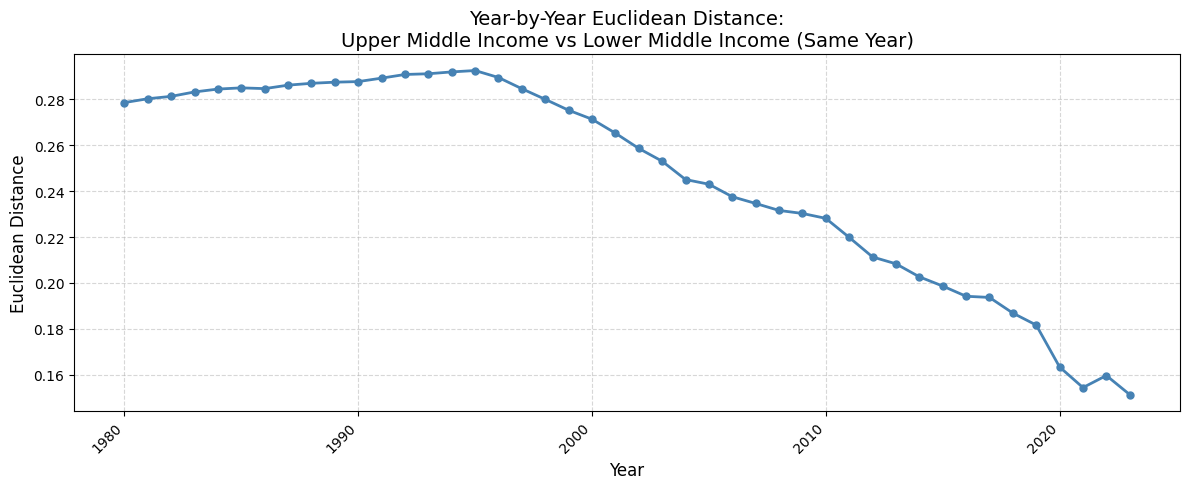

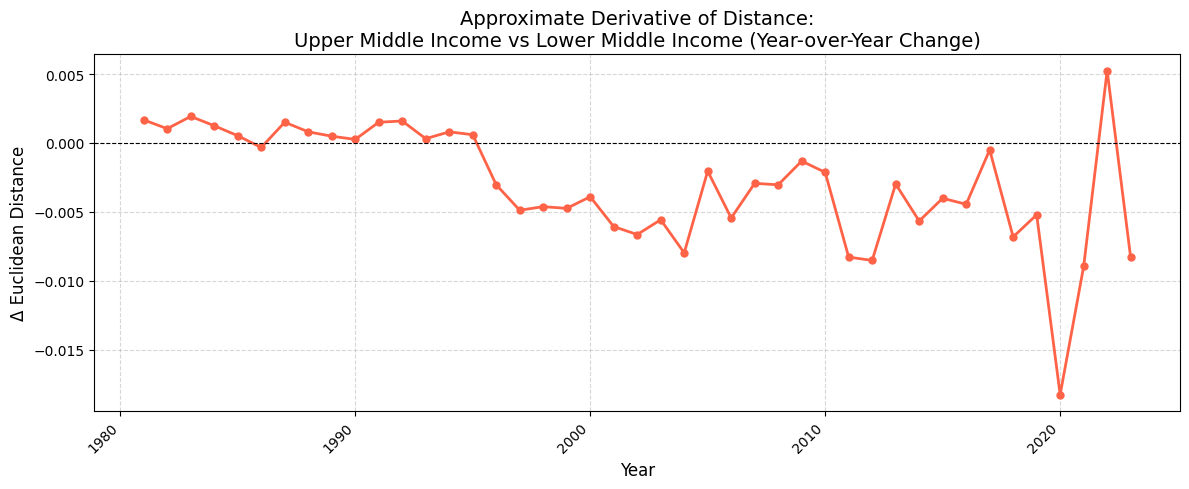

In [27]:
df = death_pivot.copy()
feature_cols = [c for c in df.columns if c not in ['cause', 'income_class', 'year']]

hi = df[df['income_class'] == 'World Bank Upper Middle Income']
umi = df[df['income_class'] == 'World Bank Lower Middle Income']

years = sorted(set(hi['year'].unique()) & set(umi['year'].unique()))

hi_by_year  = hi.groupby('year')[feature_cols].mean()
umi_by_year = umi.groupby('year')[feature_cols].mean()

diagonal_distances = [
    np.linalg.norm(hi_by_year.loc[y].values - umi_by_year.loc[y].values)
    for y in years
]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(years, diagonal_distances, marker='o', linewidth=2, markersize=5, color='steelblue')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Euclidean Distance', fontsize=12)
ax.set_title('Year-by-Year Euclidean Distance:\nUpper Middle Income vs Lower Middle Income (Same Year)', fontsize=14)
ax.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

years_mid = years[1:]
deltas = [diagonal_distances[i+1] - diagonal_distances[i] for i in range(len(diagonal_distances)-1)]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(years_mid, deltas, marker='o', linewidth=2, markersize=5, color='tomato')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Δ Euclidean Distance', fontsize=12)
ax.set_title('Approximate Derivative of Distance:\nUpper Middle Income vs Lower Middle Income (Year-over-Year Change)', fontsize=14)
ax.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

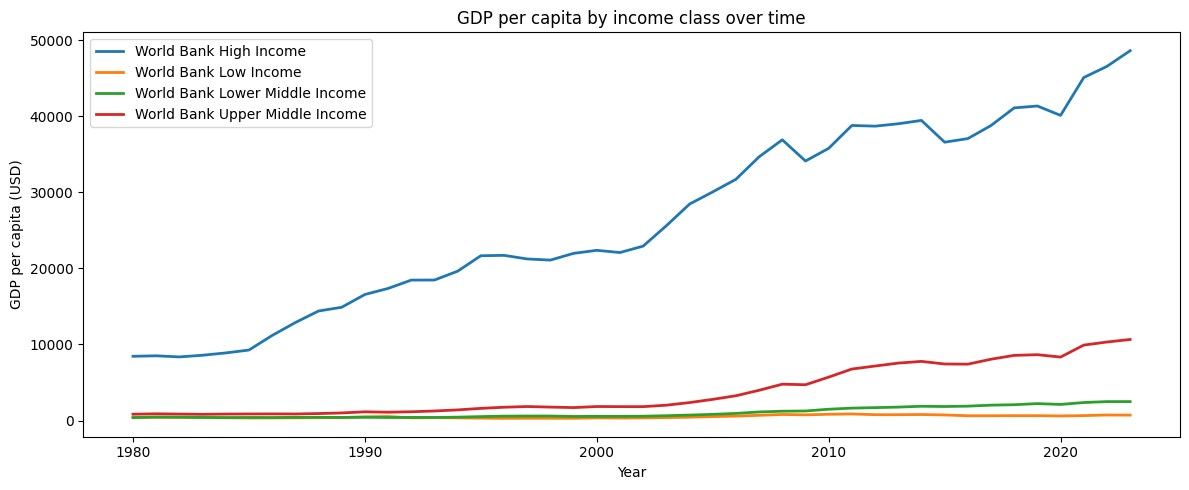

In [28]:
gdp_by_class = (
    df_income
    .groupby(['income_class', 'year'])['gdp_per_capita_usd']
    .first()
    .reset_index()
    .sort_values('year')
)

years = sorted(gdp_by_class['year'].unique().tolist())

plt.figure(figsize=(12, 5))
for cls, grp in gdp_by_class.groupby('income_class'):
    plt.plot(grp['year'], grp['gdp_per_capita_usd'], label=cls, linewidth=2)

plt.xlabel('Year')
plt.ylabel('GDP per capita (USD)')
plt.title('GDP per capita by income class over time')
plt.legend()
plt.tight_layout()
plt.show()

In [29]:
low = gdp_by_class[
    (gdp_by_class['income_class'] == 'World Bank High Income')
].copy()

low.sort_values("year", ascending=True).head(40)

,income_class,year,gdp_per_capita_usd
0,World Bank High Income,1980,8449.5621
1,World Bank High Income,1981,8511.1153
2,World Bank High Income,1982,8366.5297
3,World Bank High Income,1983,8585.1327
4,World Bank High Income,1984,8892.1678
5,World Bank High Income,1985,9269.5947
6,World Bank High Income,1986,11184.5378
7,World Bank High Income,1987,12880.4034
8,World Bank High Income,1988,14398.6650
9,World Bank High Income,1989,14891.7846
